# Favorita Store Sales Forecasting — EDA + Анализ результатов

Ноутбук для базового EDA и анализа результатов.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import sys, os
PROJECT_DIR = "/content/project"
if os.path.exists(PROJECT_DIR):
    sys.path.insert(0, PROJECT_DIR)
else:
    sys.path.insert(0, "/content/drive/MyDrive/favorita/project")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.metrics import nwrmsle, wmape, bias_me
from src.data.load import load_all_csvs
from src.data.prepare import prepare_train_test, prepare_side_tables

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Загрузка данных и EDA

In [3]:
data = load_all_csvs(config.CSV_DIR)
train, test, items, stores, oil = data["train"], data["test"], data["items"], data["stores"], data["oil"]

for name, df in [("train", train), ("test", test), ("items", items), ("stores", stores), ("oil", oil)]:
    print(f"{name:12s}: {df.shape[0]:>10,} rows × {df.shape[1]} cols")

train       : 125,497,040 rows × 6 cols
test        :  3,370,464 rows × 5 cols
items       :      4,100 rows × 4 cols
stores      :         54 rows × 5 cols
oil         :      1,218 rows × 2 cols


In [4]:
# Пропуски по датасетам
for name, df in [("train", train), ("test", test), ("items", items), ("stores", stores), ("oil", oil)]:
    nans = df.isna().sum()
    nans = nans[nans > 0]
    if len(nans) > 0:
        print(f"\n{name}:")
        print(nans.to_string())


train:
onpromotion    21657651

oil:
dcoilwtico    43


In [5]:
# Диапазон дат и статистики
print("train date min/max:", train["date"].min(), train["date"].max())
print("negative unit_sales:", (train["unit_sales"] < 0).sum())
print("train stores:", train["store_nbr"].nunique(), "test stores:", test["store_nbr"].nunique())
print("train items:", train["item_nbr"].nunique(), "test items:", test["item_nbr"].nunique())

train date min/max: 2013-01-01 00:00:00 2017-08-15 00:00:00
negative unit_sales: 7795
train stores: 54 test stores: 54
train items: 4036 test items: 3901


In [6]:
# Плотность данных (structural zeros)
n_days = (train["date"].max() - train["date"].min()).days + 1
n_stores = train["store_nbr"].nunique()
n_items = train["item_nbr"].nunique()
max_possible = n_days * n_stores * n_items
print(f"Days: {n_days}, Stores: {n_stores}, Items: {n_items}")
print(f"Max possible rows: {max_possible:,}")
print(f"Actual rows: {len(train):,}")
print(f"Density: {len(train)/max_possible*100:.1f}%")

Days: 1688, Stores: 54, Items: 4036
Max possible rows: 367,889,472
Actual rows: 125,497,040
Density: 34.1%


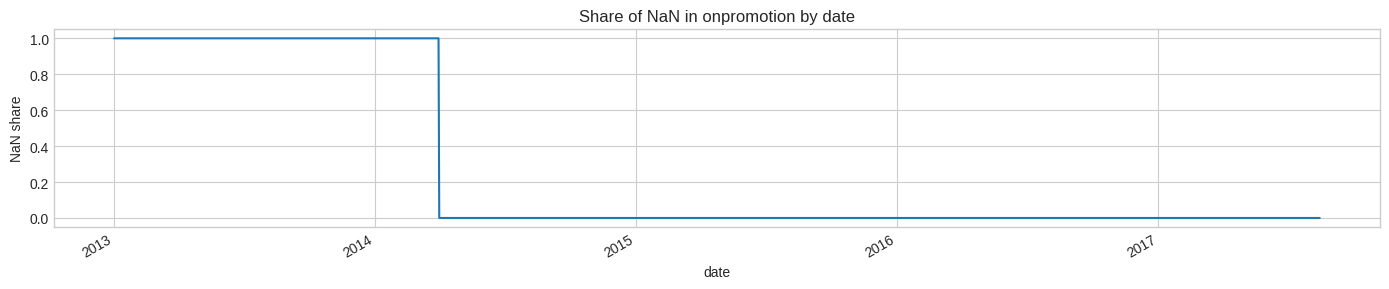

In [7]:
# NaN pattern in onpromotion by date
promo_na_by_date = train.groupby("date")["onpromotion"].apply(lambda s: s.isna().mean())
promo_na_by_date.plot(figsize=(14, 3), title="Share of NaN in onpromotion by date")
plt.ylabel("NaN share")
plt.tight_layout()
plt.show()

## 5. Выводы (см. файл `run_colab.ipynb`)

1. **Бейзлайны**: SeasonalNaive(7) лучше Naive, что подтверждает недельную сезонность в данных.
2. **CatBoost**: Модель с winner-inspired features (multi-window статистики + gap=16 для предотвращения утечки) существенно превосходит все статистические бейзлайны.
3. **Ключевые факторы прироста**:
   - Dense grid (восстановление нулей) — корректное моделирование структурных нулей
   - Gap=16 — имитация test-time условий при обучении
   - Threshold tuning — обнуление малых предсказаний
   - Экзогенные признаки (oil, promo) — дополнительный сигнал
4. **NN модель**: архитектура реализована (8th place approach)
5. Ансамблинг моделей даёт наилучшее 